# Coupled n–p scattering: the ³S₁–³D₁ deuteron channel

In the neutron–proton system with total angular momentum $J = 1$, the tensor part of the
nuclear force couples the $\ell = 0$ (³S₁) and $\ell = 2$ (³D₁) partial waves. This is the
channel that binds the deuteron, and the textbook example of a coupled-channel scattering
problem.

This notebook shows the full coupled-channel workflow with `lax`:

1. inspect the Reid soft-core interaction shipped in `lax.models`,
2. compile **one** two-channel spectral solver on a dense energy grid,
3. read the deuteron binding energy directly off the spectrum, and
4. extract Blatt–Biedenharn eigenphases and the mixing angle $\varepsilon_1$ from the
   $S$ matrix, compared against published benchmark values.

In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import lax as lm


def unwrap_phase_deg(phase_deg: np.ndarray) -> np.ndarray:
    # δ is only defined modulo 180°: unwrap 2δ to remove branch jumps.
    return np.degrees(np.unwrap(2.0 * np.radians(phase_deg))) / 2.0


channels = lm.models.reid_np_j1_channels()
for index, channel in enumerate(channels):
    print(f"channel {index}: l={channel.l}  threshold={channel.threshold} MeV")

channel 0: l=0  threshold=0.0 MeV
channel 1: l=2  threshold=0.0 MeV


## The Reid soft-core interaction

`lax.models.reid_soft_core_triplet_components(r)` returns the three radial pieces of the
Reid soft-core triplet interaction: a **central** term, a **tensor** term (which is what
mixes the S and D waves), and a **spin-orbit** term. The public builder
`lax.models.interaction_from_reid_np_j1(solver)` assembles them into the coupled
$2 \times 2$ potential as *(form factor × coupling matrix)* terms: the central term on
the channel diagonal, the tensor term scaled by
$\bigl[\begin{smallmatrix}0 & 2\sqrt{2} \\ 2\sqrt{2} & -2\end{smallmatrix}\bigr]$,
and the spin-orbit term by
$\bigl[\begin{smallmatrix}0 & 0 \\ 0 & -3\end{smallmatrix}\bigr]$.

The hallmark of the Reid potential is the strongly repulsive soft core below
$r \approx 0.7$ fm and the attractive pocket beyond it.

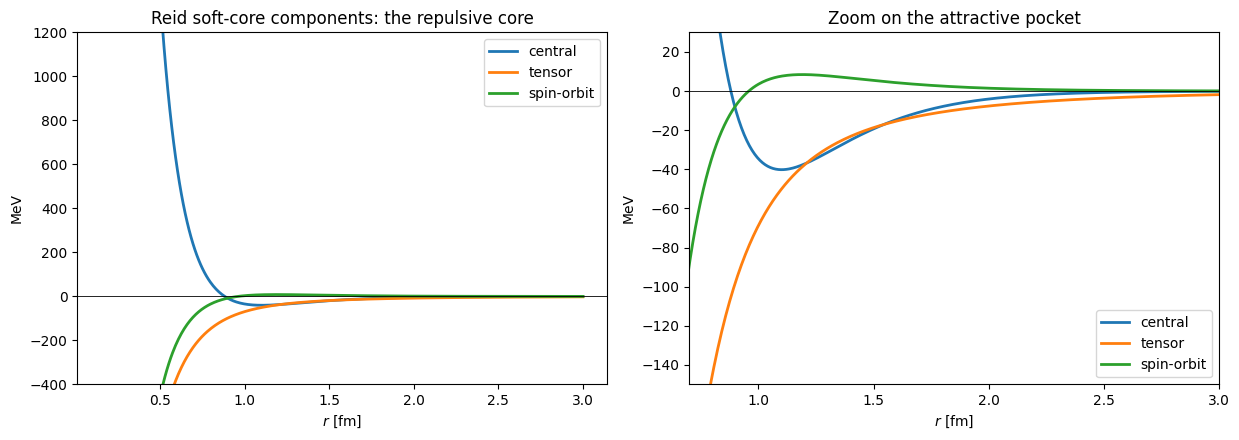

In [2]:
r = np.linspace(0.15, 3.0, 500)
central, tensor, spin_orbit = [
    np.asarray(v)
    for v in lm.models.reid_soft_core_triplet_components(jnp.asarray(r))
]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for values, label in [(central, "central"), (tensor, "tensor"), (spin_orbit, "spin-orbit")]:
    for axis in axes:
        axis.plot(r, values, label=label, linewidth=2.0)
    axes[0].lines[-1].set_label(label)

axes[0].set_ylim(-400.0, 1200.0)
axes[0].set_title("Reid soft-core components: the repulsive core")
axes[1].set_xlim(0.7, 3.0)
axes[1].set_ylim(-150.0, 30.0)
axes[1].set_title("Zoom on the attractive pocket")
for axis in axes:
    axis.axhline(0.0, color="black", linewidth=0.6)
    axis.set_xlabel(r"$r$ [fm]")
    axis.set_ylabel("MeV")
    axis.legend()
fig.tight_layout()

## Compile one coupled solver on a dense energy grid

The two channels are coupled, so they live in a single `channels=` solver. On the
spectral path **one eigendecomposition serves every energy**: the $S$ matrix on the whole
grid comes from the same `Spectrum`. The n–p system is neutral, so the compile-time
boundary values use the fast spherical-Bessel path and a dense grid is cheap.

In [3]:
energies = jnp.linspace(0.5, 50.0, 100)

solver = lm.compile(
    mesh=lm.MeshSpec("legendre", "x", n=60, scale=7.0),
    channels=channels,
    operators=("T+L", "1/r^2"),
    solvers=("spectrum", "smatrix"),
    energies=energies,
)
potential = lm.models.interaction_from_reid_np_j1(solver)
spectrum = solver.spectrum(potential)
smatrices = np.asarray(solver.smatrix(spectrum))
print("S-matrix samples:", smatrices.shape)

S-matrix samples: (100, 2, 2)


## The deuteron, for free

Bound states are simply the eigenvalues of the Bloch-augmented Hamiltonian that lie below
threshold — the same `Spectrum` that powers the scattering observables. The finite channel
radius squeezes the loosely bound deuteron (its exponential tail leaks past any few-fm
box), so the binding energy converges from above as the box grows:

In [4]:
eigen_mev = np.asarray(spectrum.eigenvalues) * lm.models.NN_MASS_FACTOR
bound = eigen_mev[eigen_mev < 0.0]
print(f"bound state on the 7 fm scattering mesh: {float(bound[0]):.4f} MeV")

# The same workflow on growing boxes converges toward the experimental -2.224 MeV.
for scale, n in [(10.0, 60), (14.0, 80)]:
    bound_solver = lm.compile(
        mesh=lm.MeshSpec("legendre", "x", n=n, scale=scale),
        channels=channels,
        operators=("T+L", "1/r^2"),
        solvers=("spectrum",),
        energies=jnp.asarray([1.0]),
    )
    bound_spectrum = bound_solver.spectrum(
        lm.models.interaction_from_reid_np_j1(bound_solver)
    )
    eigen = np.asarray(bound_spectrum.eigenvalues) * lm.models.NN_MASS_FACTOR
    print(f"bound state with a {scale:.0f} fm box:            {eigen[eigen < 0.0][0]:.4f} MeV")
print("experiment:                              -2.2246 MeV")

bound state on the 7 fm scattering mesh: -2.7278 MeV
bound state with a 10 fm box:            -2.3708 MeV
bound state with a 14 fm box:            -2.2611 MeV
experiment:                              -2.2246 MeV


## Eigenphases and the mixing angle

For a coupled pair of channels the natural observables are the **Blatt–Biedenharn**
parameters: two eigenphases $\delta_{{}^3S_1}$, $\delta_{{}^3D_1}$ and one mixing angle
$\varepsilon_1$ that diagonalize the $S$ matrix.
`lax.spectral.coupled_channel_parameters_from_S` extracts them per energy; the markers
are the published benchmark values (Descouvemont, *CPC* **200** (2016), n–p $J=1$
grid).

In [5]:
params = [lm.spectral.coupled_channel_parameters_from_S(s) for s in smatrices]
delta_s = unwrap_phase_deg(np.degrees([float(np.asarray(p.phase_2)) for p in params]))
delta_d = unwrap_phase_deg(np.degrees([float(np.asarray(p.phase_1)) for p in params]))
epsilon = np.degrees([float(np.asarray(p.mixing_angle)) for p in params])
abs_s12 = np.abs(smatrices[:, 0, 1])

# Published checkpoints: Descouvemont, CPC 200 (2016), n-p J=1 benchmark.
ref_energies = np.array([12.0, 24.0, 36.0, 48.0])
ref_delta_s = np.degrees([1.4256, 1.1052, 0.90165, 0.74889])
ref_delta_d = np.degrees([-0.048047, -0.11502, -0.16959, -0.21425])
ref_abs_s12 = np.array([0.067922, 0.082249, 0.099708, 0.11575])

# Align the unwrapped curves with the published branch.
e_np = np.asarray(energies)
anchor = np.argmin(np.abs(e_np - ref_energies[0]))
delta_s += 180.0 * np.round((ref_delta_s[0] - delta_s[anchor]) / 180.0)
delta_d += 180.0 * np.round((ref_delta_d[0] - delta_d[anchor]) / 180.0)

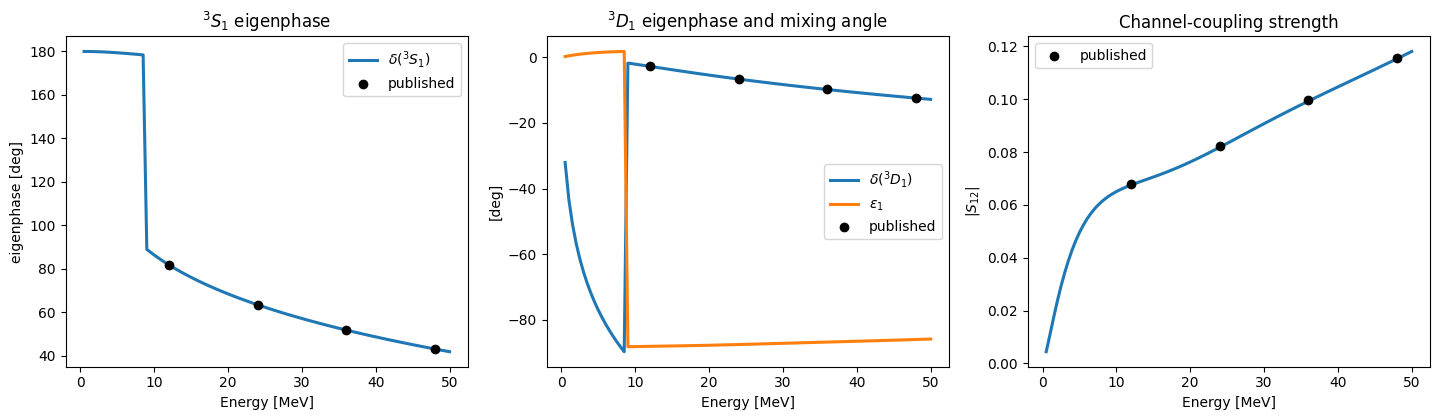

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

axes[0].plot(e_np, delta_s, linewidth=2.2, label=r"$\delta(^3S_1)$")
axes[0].scatter(ref_energies, ref_delta_s, zorder=5, color="black", label="published")
axes[0].set_ylabel("eigenphase [deg]")
axes[0].set_title(r"$^3S_1$ eigenphase")

axes[1].plot(e_np, delta_d, linewidth=2.2, label=r"$\delta(^3D_1)$")
axes[1].plot(e_np, epsilon, linewidth=2.2, label=r"$\varepsilon_1$")
axes[1].scatter(ref_energies, ref_delta_d, zorder=5, color="black", label="published")
axes[1].set_ylabel("[deg]")
axes[1].set_title(r"$^3D_1$ eigenphase and mixing angle")

axes[2].plot(e_np, abs_s12, linewidth=2.2)
axes[2].scatter(ref_energies, ref_abs_s12, zorder=5, color="black", label="published")
axes[2].set_ylabel(r"$|S_{12}|$")
axes[2].set_title("Channel-coupling strength")

for axis in axes:
    axis.set_xlabel("Energy [MeV]")
    axis.legend()
fig.tight_layout()

## How to adapt this notebook

The workflow is built from reusable pieces: swap the `mesh` to study convergence, replace
`energies` with the window you care about, or replace the Reid terms with your own
*(form factor, coupling matrix)* pairs via `solver.interaction_from_funcs(...)`. The
structure stays the same: define coupled channels, assemble a potential, compile once,
then interpret the $S$ matrix in whatever basis is most useful.